In [1]:
from umap import umap_ as umap
import igraph as ig
import leidenalg
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
y_list = np.load("3t3_y_list.npy")
y_hat_list = np.load("3t3_y_hat_list.npy")

In [3]:
all_diff = abs(y_list - y_hat_list)

In [4]:
from pathlib import Path
import numpy as np
import shutil

# Load the approach curves
approach_path = Path.cwd() / "3t3_cell_dataset" / "approach"
approach_files = sorted(approach_path.glob("*.npy"), key=lambda f: int(f.stem))
approach_curves = [np.load(f) for f in approach_files]

# Load the retraction curves
retract_path = Path.cwd() / "3t3_cell_dataset" / "retraction"
retract_files = sorted(retract_path.glob("*.npy"), key=lambda f: int(f.stem))
retract_curves = [np.load(f) for f in retract_files]

# Load the labels
labels = np.load(Path.cwd() / "3t3_cell_dataset" / "label.npy")

# Load the contact points
contactpoints = np.load(Path.cwd() / "3t3_cell_dataset" / "contact_point.npy")

young_modulus = np.load(Path.cwd() / "3t3_cell_dataset" / "young_modulus.npy")



def label_separate(labels: np.ndarray[int], 
                   label: int, 
                   *arrays: np.ndarray,
) -> tuple[list, ...]:
    """Separates data based on a specified label.

    This utility function filters multiple aligned NumPy arrays according
    to a given label. It returns subsets of the input arrays where the
    labels match the specified value.

    Parameters
    ----------
    labels : np.ndarray[int]
        Array of labels used for filtering.
    label : int
        Target label to select.
    *arrays : np.ndarray
        One or more NumPy arrays aligned with `labels`. All arrays must
        have the same length as `labels`.

    Returns
    -------
    tuple[list, ...]
        A tuple where each element corresponds to a filtered version of
        the input arrays, containing only elements whose label matches
        the specified value.

    Examples
    --------
    >>> labels = np.array([0, 0, 1, 1, 1])
    >>> label = 1
    >>> list1 = np.array([1, 2, 3, 4, 5])
    >>> list2 = np.array([5, 4, 3, 2, 1])
    >>> s_l1, s_l2 = label_separate(labels, label, list1, list2)
    >>> s_l1, s_l2
    ([3, 4, 5], [3, 2, 1])

    """

    idx = np.where(labels == label)[0]
    return tuple([[arr[i] for i in idx] for arr in arrays])



# Calculate the length of each curve
approach_curve_lengths = [curve.shape[0] for curve in approach_curves]
retract_curve_lengths = [curve.shape[0] for curve in retract_curves]

# Calculate the minimum length of approach curves and retraction curves
min_approach_curve_length = min(approach_curve_lengths)
min_retract_curve_length = min(retract_curve_lengths)

resampled_approach_curves = []
resampled_contactpoints = []
for approach_curve, contactpoint in zip(approach_curves, contactpoints):
    # Resample each approach curve to adjust its length to the shortest one
    steps = np.round(
        np.linspace(0, approach_curve.shape[0] - 1, min_approach_curve_length)
    ).astype(int)
    resampled_approach_curve = approach_curve[steps][:, 1]
    resampled_approach_curves.append(resampled_approach_curve)

    # Determine the contact point for the resampled approach curve
    resampled_approach_position = approach_curve[steps][:, 0]
    resampled_contactpoint = (
        np.abs(resampled_approach_position - contactpoint).argmin()
    )
    resampled_contactpoints.append(resampled_contactpoint)

norm_approach_curves = []

for resampled_approach_curve in resampled_approach_curves:
    norm_approach_curves.append(
        (resampled_approach_curve - resampled_approach_curve.min())
        / (resampled_approach_curve.max() - resampled_approach_curve.min())
    )

# Normalize each contact point according to min approach length
norm_contact_points = []

for resampled_contactpoint in resampled_contactpoints:
    norm_contact_points.append(
        resampled_contactpoint / min_approach_curve_length
    )

In [5]:
import numpy as np


def moving_average(arr, k):
    arr = np.asarray(arr, dtype=float)

    if k <= 0 or k > len(arr):
        raise ValueError("k 必须大于 0 且不超过数组长度")
    prefix = np.concatenate(([0], np.cumsum(arr)))

    window_sum = prefix[k:] - prefix[:-k]

    return window_sum / k


arr = np.array([1, 2, 3, 4, 5, 6])
print(moving_average(arr, 3))

[2. 3. 4. 5.]


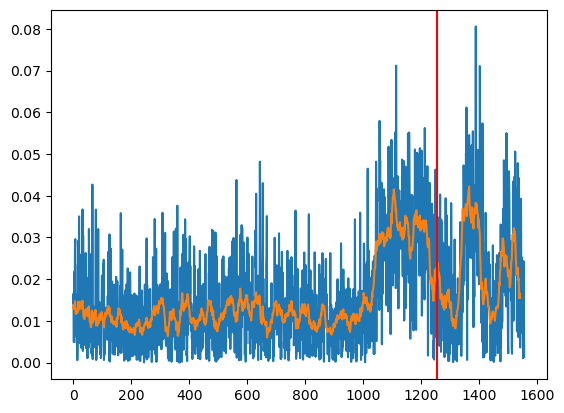

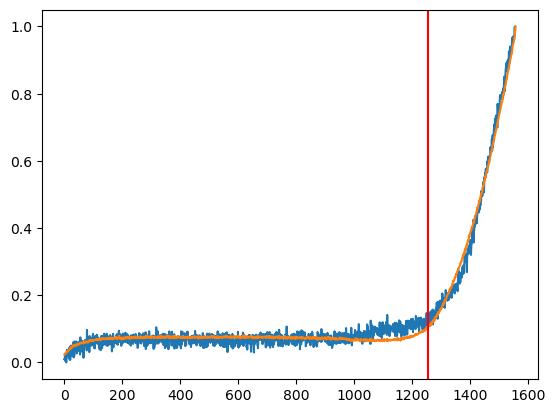

In [6]:
indx = 50

plt.plot(all_diff[indx])
plt.plot(moving_average(all_diff[indx], 15))
plt.axvline(resampled_contactpoints[indx], c="red")
plt.show()

plt.plot(y_list[indx])
plt.plot(y_hat_list[indx])
plt.axvline(resampled_contactpoints[indx], c="red")
plt.show()


In [786]:
align_length = 10
feature = []
cp_pos = []
choose = []

for indx in range(y_list.shape[0]):
    #print(all_diff[indx].shape)
    #print(resampled_contactpoints[indx])

    ori_y = y_list[indx]*(resampled_approach_curves[indx].max()-resampled_approach_curves[indx].min()) + resampled_approach_curves[indx].min()
    ori_y_hat = y_hat_list[indx]*(resampled_approach_curves[indx].max()-resampled_approach_curves[indx].min()) + resampled_approach_curves[indx].min()
    
    diff = (ori_y-ori_y_hat)

    #diff = ori_y
    
#    cp_diff = diff[:max(10,resampled_contactpoints[indx])]

#    cp_diff = diff[resampled_contactpoints[indx]:]

#    cp_diff = diff[int(0.9*resampled_contactpoints[indx]):resampled_contactpoints[indx]+int(0.1*(diff.shape[0]-resampled_contactpoints[indx]))]

    if resampled_contactpoints[indx]+25 < diff.shape[0]:
        
        cp_diff = diff[resampled_contactpoints[indx]-25:resampled_contactpoints[indx]+25]

        #cp_diff = diff[resampled_contactpoints[indx]+10:]

    #    cp_pos.append((0.1*resampled_contactpoints[indx])/(resampled_contactpoints[indx]+int(0.1*(diff.shape[0]-resampled_contactpoints[indx]))-0.9*resampled_contactpoints[indx]))
    
        #cp_diff = diff
    
    
    #    cp_diff = y_list[indx]
        
        #cp_diff = all_diff[indx]
    
    
        x_old = np.linspace(0, 1, cp_diff.size)
        x_new = np.linspace(0, 1, align_length)
    
        cp_diff = np.interp(x_new, x_old, cp_diff)
    
        smooth_diff = moving_average(cp_diff, 2)
        
        #smooth_diff = cp_diff
    
        
        feature.append(
            (smooth_diff - smooth_diff.min())/(smooth_diff.max()-smooth_diff.min()+1e-6)
        )
    
#        feature.append(
#            smooth_diff
#        )
        
        choose.append(True)

    else:

        print("fuck")

        choose.append(False)


        


    


fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck
fuck


In [760]:
align_length = 100
feature = []
cp_pos = []
choose = []

for indx in range(y_list.shape[0]):
    #print(all_diff[indx].shape)
    #print(resampled_contactpoints[indx])

    ori_y = y_list[indx]*(resampled_approach_curves[indx].max()-resampled_approach_curves[indx].min()) + resampled_approach_curves[indx].min()
    ori_y_hat = y_hat_list[indx]*(resampled_approach_curves[indx].max()-resampled_approach_curves[indx].min()) + resampled_approach_curves[indx].min()
    
    diff = (ori_y-ori_y_hat)

    #diff = ori_y
    
#    cp_diff = diff[:max(10,resampled_contactpoints[indx])]

    cp_diff = diff[resampled_contactpoints[indx]-100:]

    choose.append(True)

#    cp_diff = diff[int(0.9*resampled_contactpoints[indx]):resampled_contactpoints[indx]+int(0.1*(diff.shape[0]-resampled_contactpoints[indx]))]




        


    
#    cp_pos.append((0.1*resampled_contactpoints[indx])/(resampled_contactpoints[indx]+int(0.1*(diff.shape[0]-resampled_contactpoints[indx]))-0.9*resampled_contactpoints[indx]))

    #cp_diff = diff


#    cp_diff = y_list[indx]
    
    #cp_diff = all_diff[indx]


    x_old = np.linspace(0, 1, cp_diff.size)
    x_new = np.linspace(0, 1, align_length)

    cp_diff = np.interp(x_new, x_old, cp_diff)

    smooth_diff = moving_average(cp_diff, 20)
    
    #smooth_diff = cp_diff

    
#    feature.append(
#        (smooth_diff - smooth_diff.min())/(smooth_diff.max()-smooth_diff.min()+1e-6)
#    )

    feature.append(
        smooth_diff
    )

In [787]:
choose = np.array(choose)

In [788]:
feature = np.array(feature)

In [789]:
feature = feature[np.where(labels[choose]!=0)[0]]

In [790]:
reducer = umap.UMAP(
        n_neighbors=100,
        min_dist=0.0,
        n_components=2)

In [791]:
mapper = reducer.fit(feature)

In [792]:
embedding = reducer.transform(feature)

In [793]:
embedding.shape

(1922, 2)

In [794]:
G = ig.Graph.Weighted_Adjacency(
    mapper.graph_.toarray().tolist(),
    mode="UNDIRECTED",
    attr="weight",
    loops=False
)

partition = leidenalg.find_partition(
    G,
    leidenalg.ModularityVertexPartition,
    weights="weight",
    seed=42
)

clustering_solution = partition.membership

clustering_solution = np.array(clustering_solution)

In [795]:
np.unique(clustering_solution)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [796]:
clustering_solution

array([0, 1, 0, ..., 4, 7, 7], shape=(1922,))

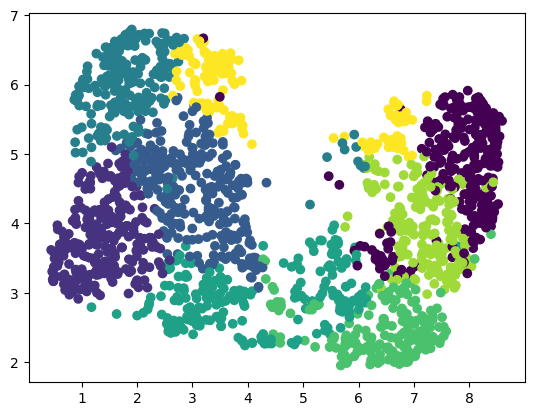

In [797]:
plt.scatter(embedding[:,0], embedding[:,1], c=clustering_solution)

In [729]:
curves__ = feature[np.where(clustering_solution==0)[0]]

In [730]:
curves__.shape

(349, 81)

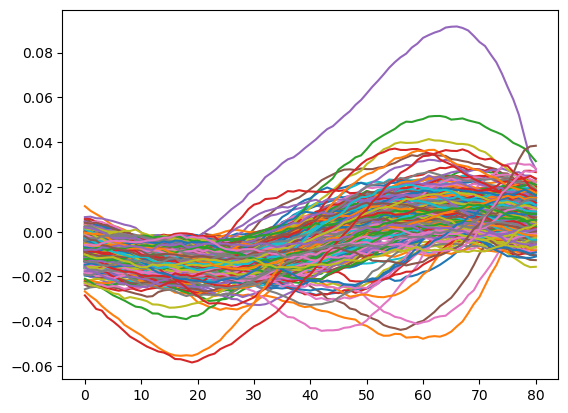

In [731]:
for i in range(curves__.shape[0]):
    plt.plot(curves__[i])

In [633]:
curves = y_list[np.where(labels!=0)[0]][np.where(clustering_solution==2)[0]]

In [465]:
curves_ = y_hat_list[np.where(labels!=0)[0]][np.where(clustering_solution==2)[0]]

In [466]:
curves.shape

(195, 1557)

In [ ]:
for i in range(curves.shape[0]):
    plt.plot(curves[i])
    plt.plot(curves_[i])
    plt.plot(curves__[i])
    plt.show()

In [334]:
curves = y_list[np.where(labels!=0)[0]][np.where(clustering_solution==2)[0]]

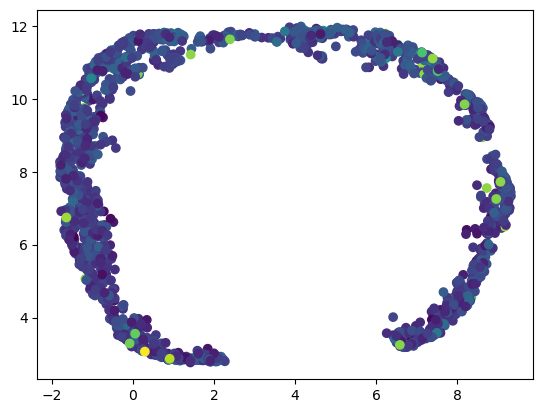

In [553]:
plt.scatter(embedding[:,0], embedding[:,1], c=np.log(young_modulus[np.where(labels!=0)[0]]))

In [318]:
plt.scatter(embedding[:,0], embedding[:,1], c=np.array(cp_pos)[np.where(labels!=0)[0]])

IndexError: index 0 is out of bounds for axis 0 with size 0

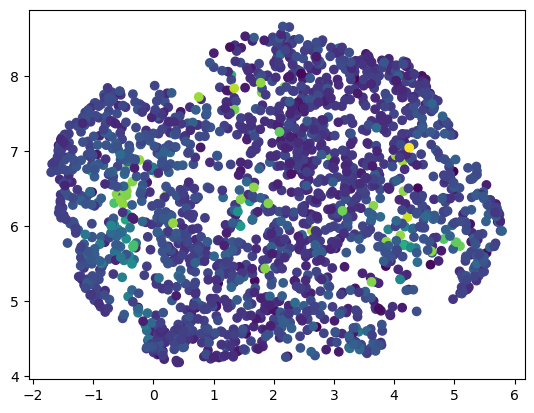

In [319]:
plt.scatter(embedding[:,0], embedding[:,1], c=np.log(young_modulus[np.where(labels!=0)[0]]))

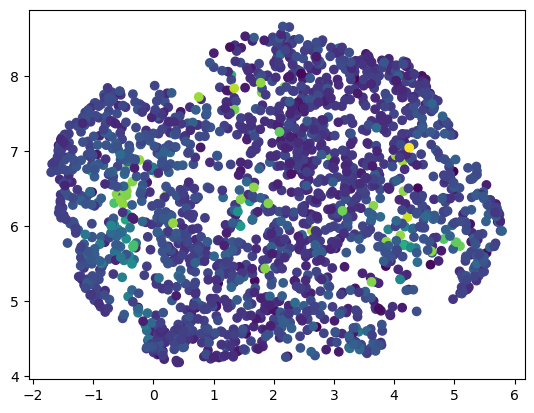

In [320]:
plt.scatter(embedding[:,0], embedding[:,1], c=np.log(young_modulus[np.where(labels!=0)[0]]))

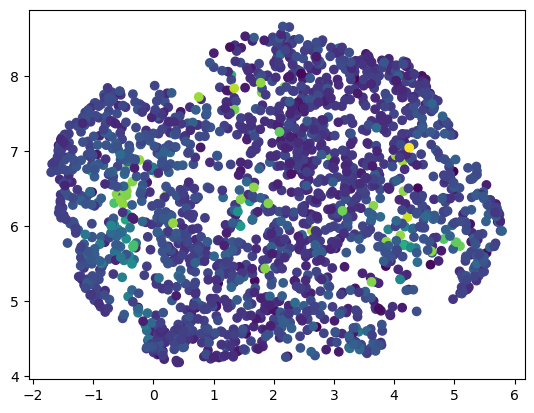

In [321]:
plt.scatter(embedding[:,0], embedding[:,1], c=np.log(young_modulus[np.where(labels!=0)[0]]))

In [799]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# Extract 2D latent variables (log-variance dimensions for visualization)
#x = embedding[:, 0][np.where(labels[np.where(labels!=0)[0]]==2)[0]]
#y = embedding[:, 1][np.where(labels[np.where(labels!=0)[0]]==2)[0]]

x = embedding[:, 0]
y = embedding[:, 1]

# Curves corresponding to each latent point
#curves = feature
curves = y_list[np.where(labels[choose]!=0)[0]]

# X-axis for plotting curves
x_curve = np.linspace(0, curves.shape[1], curves.shape[1])


# Create subplot layout: left=embedding space, right=curve visualization
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Embedding Space", "Corresponding Curve"),
)

# Scatter plot of latent space points
scatter = go.Scatter(
    x=x,
    y=y,
    mode="markers",
    name="points",
)
fig.add_trace(scatter, row=1, col=1)

# Line plot placeholder for selected curve
curve1 = go.Scatter(
    x=[],
    y=[],
    mode="lines",
    line=dict(color="red"),
    name="curve",
)
fig.add_trace(curve1, row=1, col=2)


# Line plot placeholder for selected curve
curve2 = go.Scatter(
    x=[],
    y=[],
    mode="lines",
    line=dict(color="red"),
    name="curve",
)
fig.add_trace(curve2, row=1, col=3)

# Marker to highlight selected point in latent space
selected_marker = go.Scatter(
    x=[],
    y=[],
    mode="markers",
    marker=dict(size=10, symbol="x", color="black", line=dict(width=2)),
    name="selected",
)
fig.add_trace(selected_marker, row=1, col=1)

# Convert to interactive FigureWidget
fig_widget = go.FigureWidget(fig)
fig_widget.update_layout(width=900, height=400)


def update_curve(trace, points, selector):
    """Callback function triggered when a point in embedding space is clicked.

    Parameters
    ----------
    trace: plotly trace
        The scatter plot trace that received the click.
    points: plotly.callbacks.Points
        Information about the clicked points.
    selector: plotly.callbacks.InputDeviceState
        Additional selection info (not used here).

    """

    if points.point_inds:
        idx = points.point_inds[0]  # Index of selected point

        with fig_widget.batch_update():
            # Update curve plot with corresponding color
            fig_widget.data[1].x = x_curve
            fig_widget.data[1].y = feature[idx]
            fig_widget.layout.annotations[1].text = f"Curve {idx}"


            # Update curve plot with corresponding color
            fig_widget.data[2].x = x_curve
            #fig_widget.data[2].y = curves[idx][::-1]
            fig_widget.data[2].y = curves[idx]
            fig_widget.layout.annotations[2].text = f"Curve {idx}"


            # Highlight selected point in embedding space
            fig_widget.data[3].x = [x[idx]]
            fig_widget.data[3].y = [y[idx]]


# Attach click callback to scatter plot
fig_widget.data[0].on_click(update_curve)

# Display interactive widget
display(fig_widget)


FigureWidget({
    'data': [{'mode': 'markers',
              'name': 'points',
              'type': 'scatter',
              'uid': 'b6458242-6f9f-49de-a4e8-6f9f643fd6dc',
              'x': {'bdata': ('iITrQHEVnj+WysxAAXdzQCfdwT96Uw' ... '9A2HdlQEWbX0Aq2rBAjbnWQNLJ2EA='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('e+uSQCjARkBtCWJAcBNBQLV0wECuVr' ... 'pArabLQDJcukDacVBAYMC2QNb3pEA='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'line': {'color': 'red'},
              'mode': 'lines',
              'name': 'curve',
              'type': 'scatter',
              'uid': '9c725d80-7d9c-4ef9-86d1-12aae6735fcf',
              'x': [],
              'xaxis': 'x2',
              'y': [],
              'yaxis': 'y2'},
             {'line': {'color': 'red'},
              'mode': 'lines',
              'name': 'curve',
              'type': 'scatter',
              'uid': 'dcd751c1-5400-403a-b19e-8a4318a9d00